# 05: Gaia RR Lyrae Period-Color Relations

This notebook derives class-specific Gaia period-color relations for RR Lyrae stars in the cleaned calibration sample. The fitted observable is the apparent Gaia color $G_{\mathrm{BP}} - G_{\mathrm{RP}}$, modeled as a function of $\log_{10}(P/\mathrm{day})$ for the two single-mode subclasses **RRab** and **RRc**.

The astrophysical split follows `02-02.ipynb`: RRab and RRc are fit separately because they are different pulsation modes and need not share the same color-period relation. RRd remains out of scope here because the cleaned sample is too small for a stable standalone RRd fit and because RRd is astrophysically distinct.


In [ ]:
from pathlib import Path
from types import SimpleNamespace

from astropy import table
import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import (
    build_optical_pc_comparison_data,
    build_pc_context,
    fit_pc_nuts,
    load_or_create_rrab_rrc_full_catalog,
    load_table_npz,
    mcmc_sampler_color,
    pc_posterior_summary_row,
    plot_corner,
    plot_pc_posterior_predictive,
    plot_pc_posterior_predictive_comparison,
    plot_trace,
    save_optical_pc_comparison_data,
)

In [2]:
shared_catalog_path = Path("rrlyrae_rrab_rrc_full_catalog.npz")
rrlyrae_rrab_rrc_full, shared_catalog_status = load_or_create_rrab_rrc_full_catalog(shared_catalog_path)
shared_catalog_classes = np.asarray(rrlyrae_rrab_rrc_full["best_classification"]).astype(str)
shared_catalog_counts = table.Table(
    rows=[
        {"class": rr_class, "N": int(np.count_nonzero(shared_catalog_classes == rr_class))}
        for rr_class in ("RRab", "RRc")
    ]
)

print(
    f"Shared RRab/RRc catalog {shared_catalog_status}: "
    f"{len(rrlyrae_rrab_rrc_full):,} stars"
)
shared_catalog_counts


Shared RRab/RRc catalog loaded: 269,772 stars


class,N
str4,int64
RRab,175350
RRc,94422


In [3]:
data_path = Path('rrlyrae_calibration_sample.npz')
rrlyrae_clean_data = load_table_npz(data_path)

classes = np.asarray(rrlyrae_clean_data['best_classification']).astype(str)
class_labels, class_counts = np.unique(classes, return_counts=True)
class_count_table = table.Table({'class': class_labels, 'N': class_counts})

class_count_table


class,N
str4,int64
RRab,560
RRc,315
RRd,8


## Model Setup

I follow the same subclass-specific and centered-predictor strategy used in `02-02.ipynb`. For each class separately, I define

$$
x = \log_{10}(P/\mathrm{day}), \qquad x_c = x - \bar{x}_{\mathrm{class}},
$$

and fit the period-color relation

$$
\mu = a_c\,x_c + b_c.
$$

With this parameterization, $b_c$ is the expected Gaia color at the **mean log-period of that subclass**, not at $\log_{10} P = 0$. Centering the predictor also reduces the posterior correlation between slope and intercept, although it does not force that covariance to vanish completely.

The likelihood is

$$
(G_{\mathrm{BP}} - G_{\mathrm{RP}})_i \sim \mathcal{N}\!\left(\mu_i,\; \sigma_i^2 + \sigma_{c,\mathrm{scatter}}^2\right),
$$

where $\sigma_i$ is the Gaia color uncertainty derived from the BP and RP flux-over-error columns only. Because the fitted quantity is the **apparent Gaia color**, parallax uncertainty is intentionally excluded from this notebook. I keep the same weakly informative prior scales as `02-02.ipynb`: a broad normal prior on slope, a class-local normal prior on the centered intercept, and a half-normal prior on the intrinsic scatter.


In [4]:
DISPLAY_LABELS = [r"$a_c$", r"$b_c$", r"$\sigma_{c,\mathrm{scatter}}$"]
RR_CLASSES = ("RRab", "RRc")
FIT_SEED_MAP = {"RRab": 42, "RRc": 84}
FIT_STEPS = 10_000
FIT_BURN = 2_000

In [5]:
rrab_data = rrlyrae_clean_data[classes == "RRab"]
rrc_data = rrlyrae_clean_data[classes == "RRc"]
rrd_data = rrlyrae_clean_data[classes == "RRd"]

pc_context = {
    "RRab": build_pc_context(rrab_data, "RRab"),
    "RRc": build_pc_context(rrc_data, "RRc"),
}

theta0_table = table.Table(
    rows=[
        {
            "class": rr_class,
            "N": pc_context[rr_class].n,
            "mean_log_period": round(float(pc_context[rr_class].x_mean), 4),
            "theta0_a_c": round(float(pc_context[rr_class].theta0[0]), 4),
            "theta0_b_c": round(float(pc_context[rr_class].theta0[1]), 4),
            "theta0_sigma_c": round(float(10.0 ** pc_context[rr_class].theta0[2]), 4),
        }
        for rr_class in RR_CLASSES
    ]
)

{"RRab": pc_context["RRab"].n, "RRc": pc_context["RRc"].n, "RRd excluded": len(rrd_data)}
theta0_table


class,N,mean_log_period,theta0_a_c,theta0_b_c,theta0_sigma_c
str4,int64,float64,float64,float64,float64
RRab,560,-0.2454,0.2285,0.6542,0.0664
RRc,315,-0.4933,0.3625,0.4117,0.0578


## Native PyMC Fits

Following the last modeling path in `02-02.ipynb`, this notebook skips the Metropolis-Hastings and `pm.Potential` branches and fits the class-specific period-color relations directly with native PyMC NUTS. The model definition stays local so the centered parameterization and weakly informative priors remain explicit in the notebook in the same style as `02-02.ipynb`.

The total variance matches the benchmark likelihood structure: the posterior predictive width combines the quoted color uncertainty, the intrinsic color scatter, and the propagated period-error term. Keeping that variance model explicit is important because the predictive diagnostics below are only meaningful if they reflect the same ingredients that were actually fit.


In [6]:
pc_results = {}
for rr_class in RR_CLASSES:
    fit = fit_pc_nuts(
        pc_context[rr_class],
        n_steps=FIT_STEPS,
        n_burn=FIT_BURN,
        seed=FIT_SEED_MAP[rr_class],
    )
    pc_results[rr_class] = {
        "ctx": pc_context[rr_class],
        "display": fit.display,
        "samples": fit.samples,
        "comparison_samples": fit.comparison_samples,
        "summary": pc_posterior_summary_row(rr_class, fit.samples, fit.acceptance_rate),
        "acceptance_rate": fit.acceptance_rate,
    }

pc_comparison_export = {
    rr_class: build_optical_pc_comparison_data(
        pc_results[rr_class]["ctx"],
        pc_results[rr_class]["comparison_samples"],
    )
    for rr_class in RR_CLASSES
}

summary_table = table.Table(
    rows=[pc_results[rr_class]["summary"] for rr_class in RR_CLASSES]
)

summary_table

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [a_c, b_c, sigma_c_scatter]


Output()

Sampling 1 chain for 2_000 tune and 10_000 draw iterations (2_000 + 10_000 draws total) took 3 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [a_c, b_c, sigma_c_scatter]


Output()

Sampling 1 chain for 2_000 tune and 10_000 draw iterations (2_000 + 10_000 draws total) took 3 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


class,acceptance,a_c,a_c_minus,a_c_plus,b_c,b_c_minus,b_c_plus,sigma_c,sigma_c_minus,sigma_c_plus
str4,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
RRab,0.822,0.2483,0.0417,0.0416,0.6486,0.0029,0.0029,0.0502,0.0024,0.0025
RRc,0.825,0.4782,0.0522,0.0524,0.4452,0.0033,0.0034,0.0508,0.0025,0.0027


## Diagnostics

The diagnostics are interpreted in the same way as the native-PyMC branch of `02-02.ipynb` and the WISE workflow in `03.ipynb`: the trace plot checks whether the post-burn chain looks stationary and mixed, the corner plot summarizes posterior width and covariance structure, and the posterior predictive figures test whether the fitted distribution is broad enough to describe the observed subclass color sequence once measurement error, propagated period error, and intrinsic scatter are all included.

In particular, any residual elongation in the $(a_c, b_c)$ corner panel should be read as posterior correlation that survived centering, not automatically as a sampling defect. As elsewhere in the lab, these single-chain plots are informative but not exhaustive: a stronger workflow would also inspect effective sample size, lag autocorrelation, $\hat{R}$, and NUTS divergences.


In [ ]:
for rr_class in RR_CLASSES:
    display = pc_results[rr_class]["display"]
    axes = plot_trace(
        display.samples,
        display.log_probs,
        display.param_labels,
        display.n_burn,
        color=mcmc_sampler_color(rr_class, "native"),
    )
    axes[0].set_title(f"Trace: {rr_class} period-color relation (native PyMC NUTS)")
    plt.show()

In [ ]:
for rr_class in RR_CLASSES:
    fig = plot_corner(
        pc_results[rr_class]["display"],
        color=mcmc_sampler_color(rr_class, "native"),
    )
    fig.suptitle(f"Posterior: {rr_class} period-color relation (native PyMC NUTS)")
    plt.show()

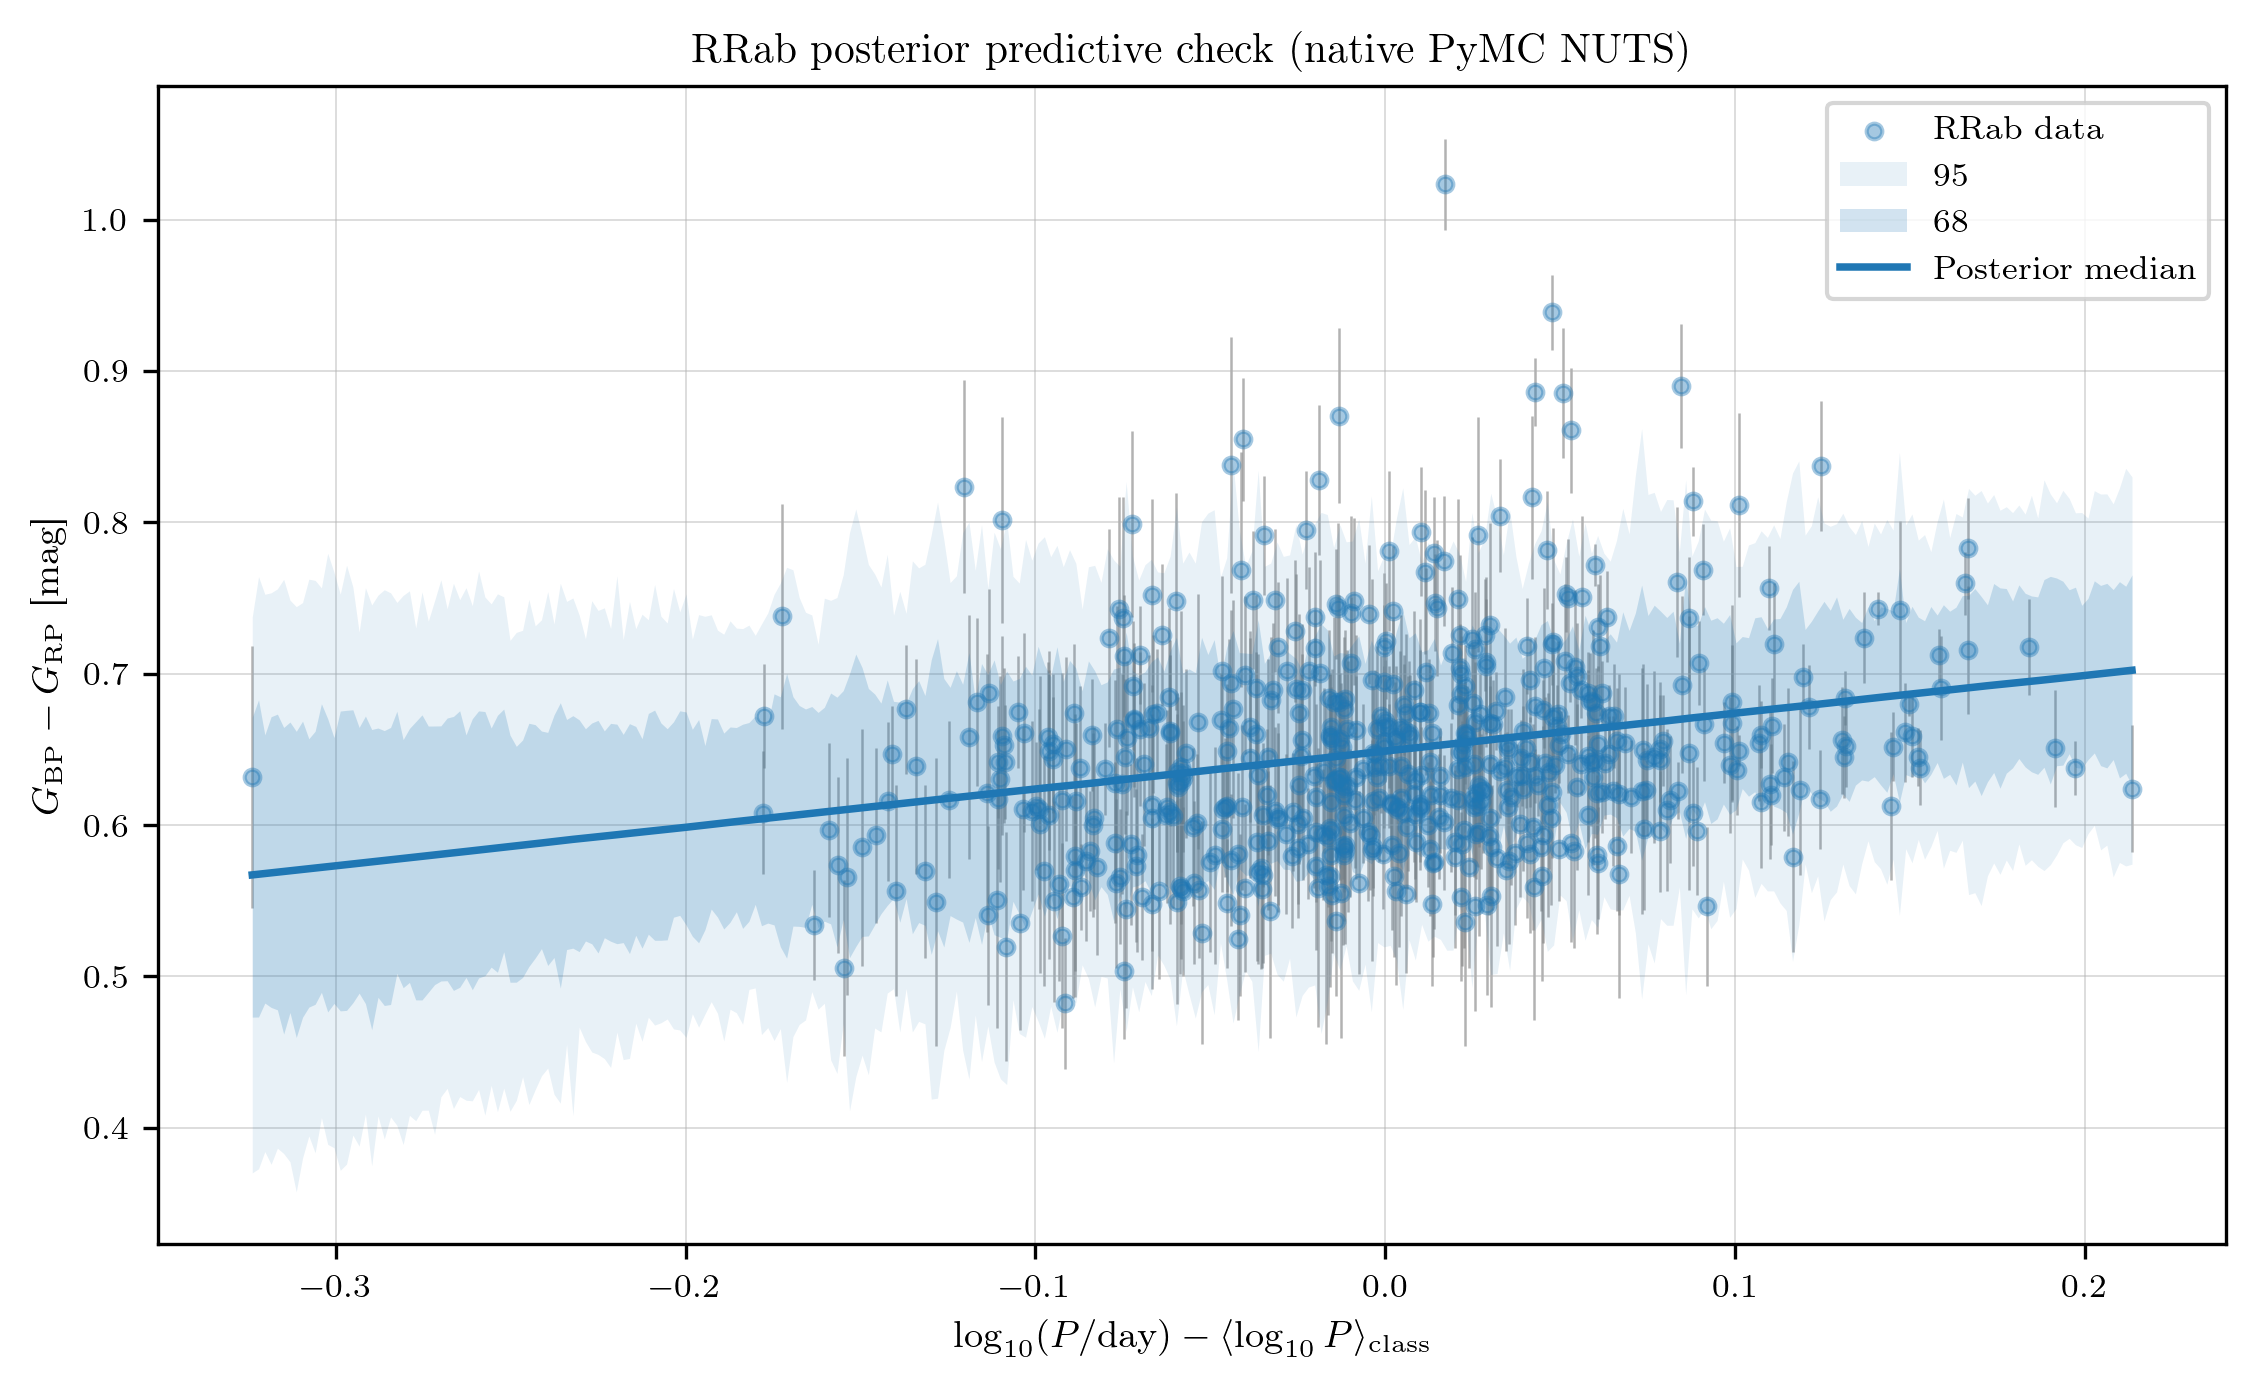

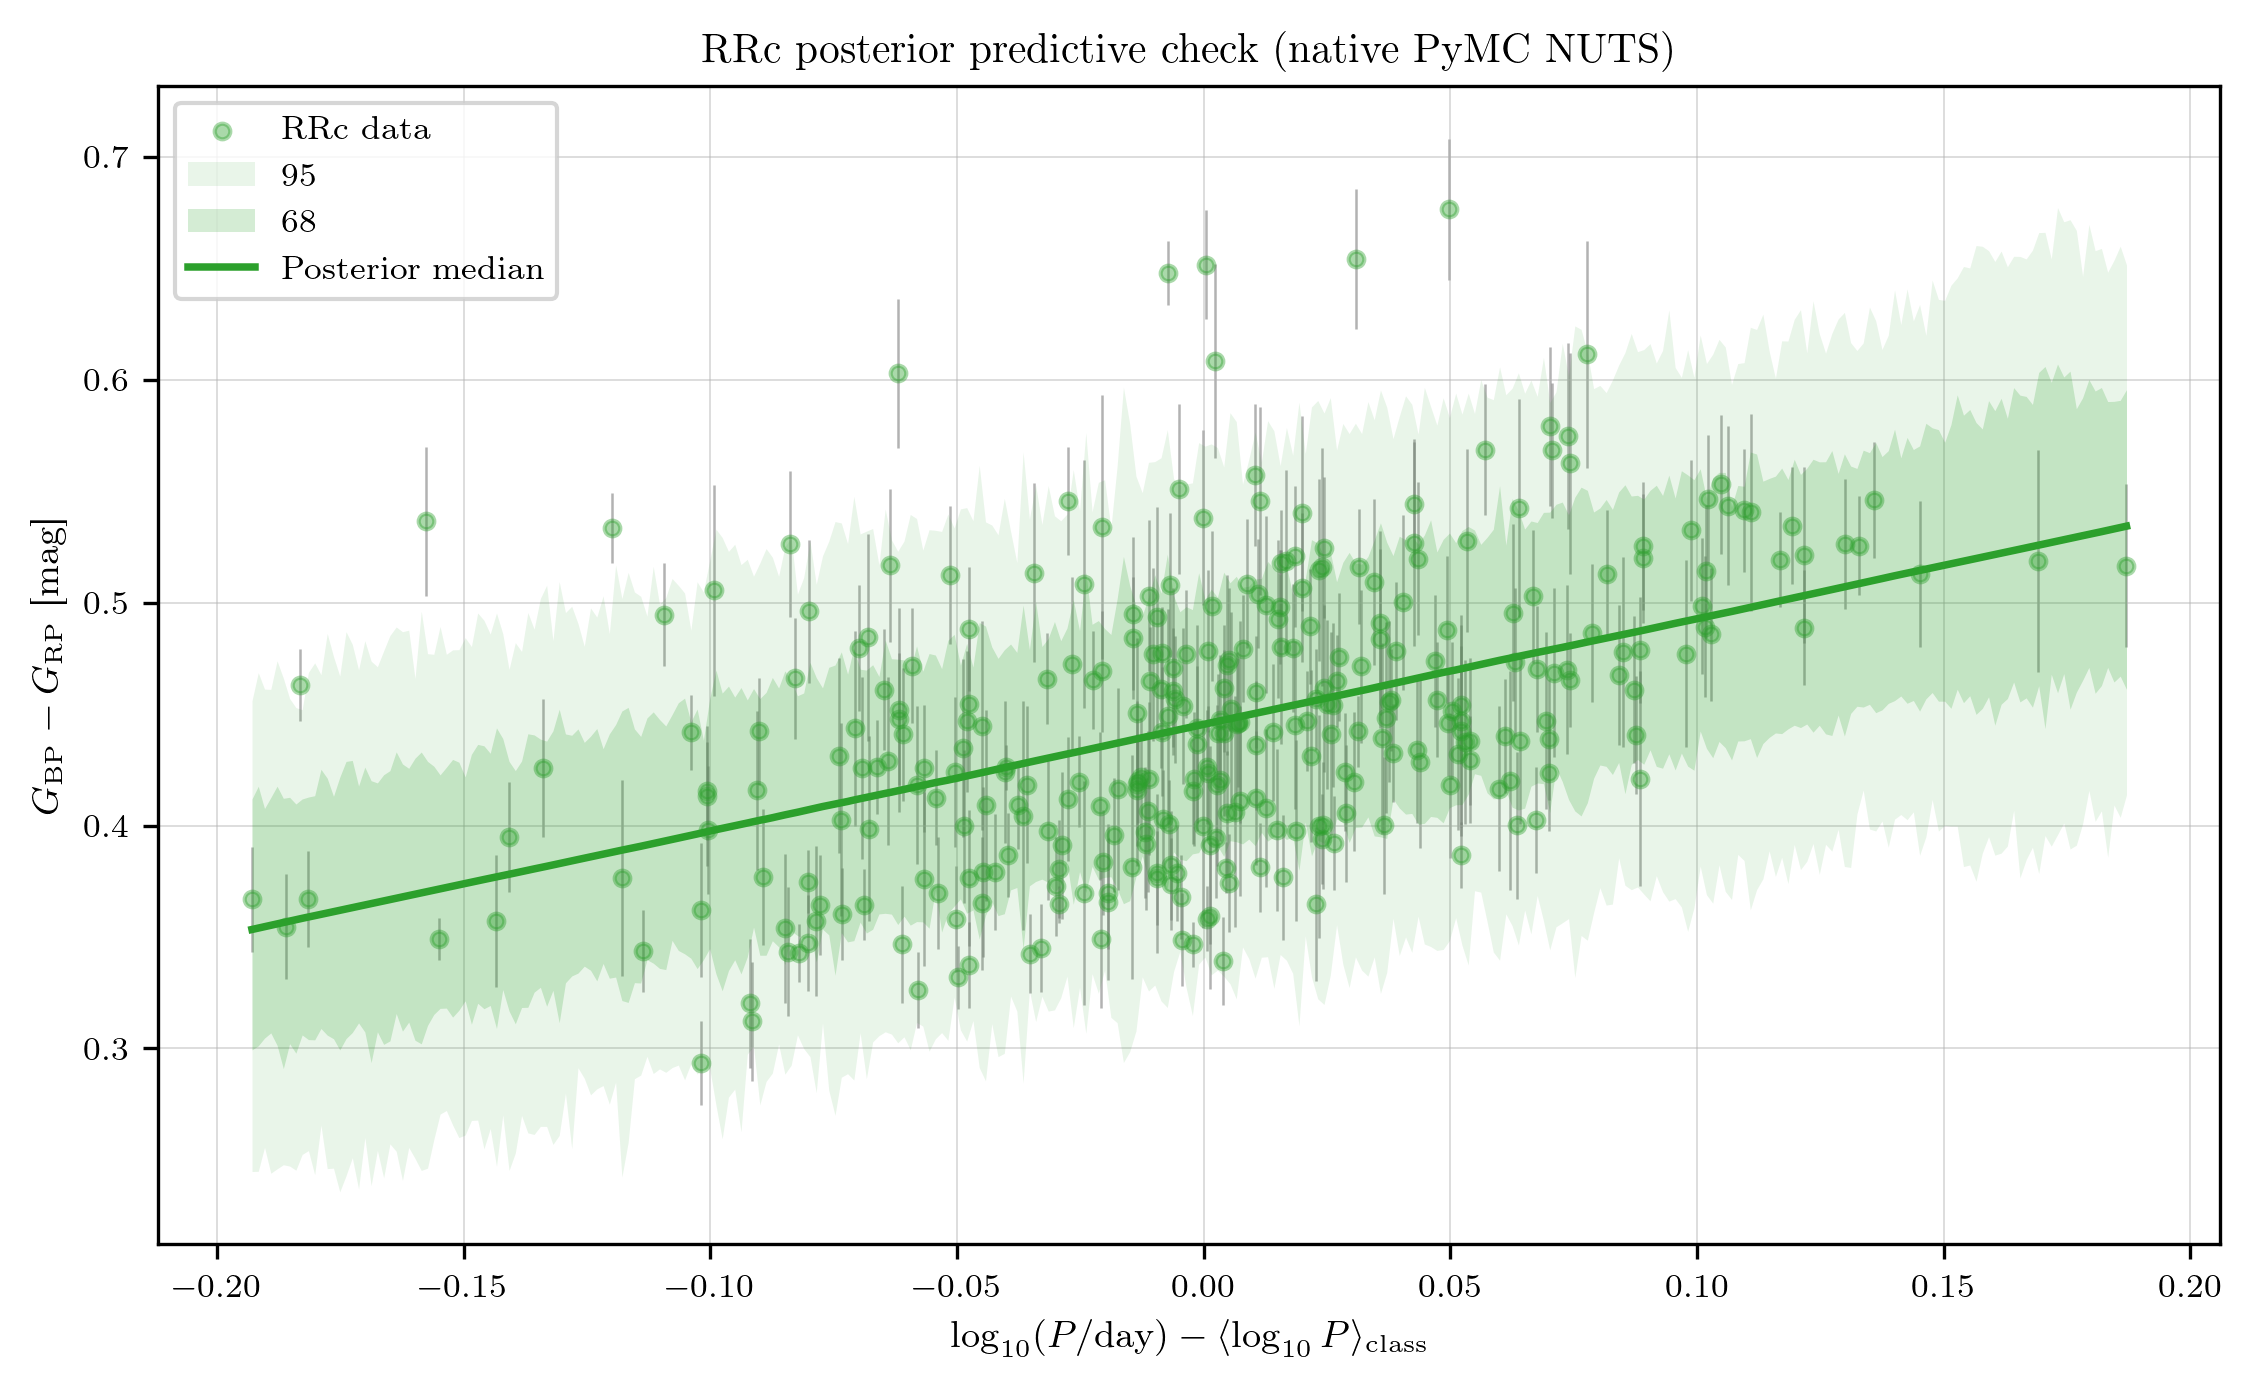

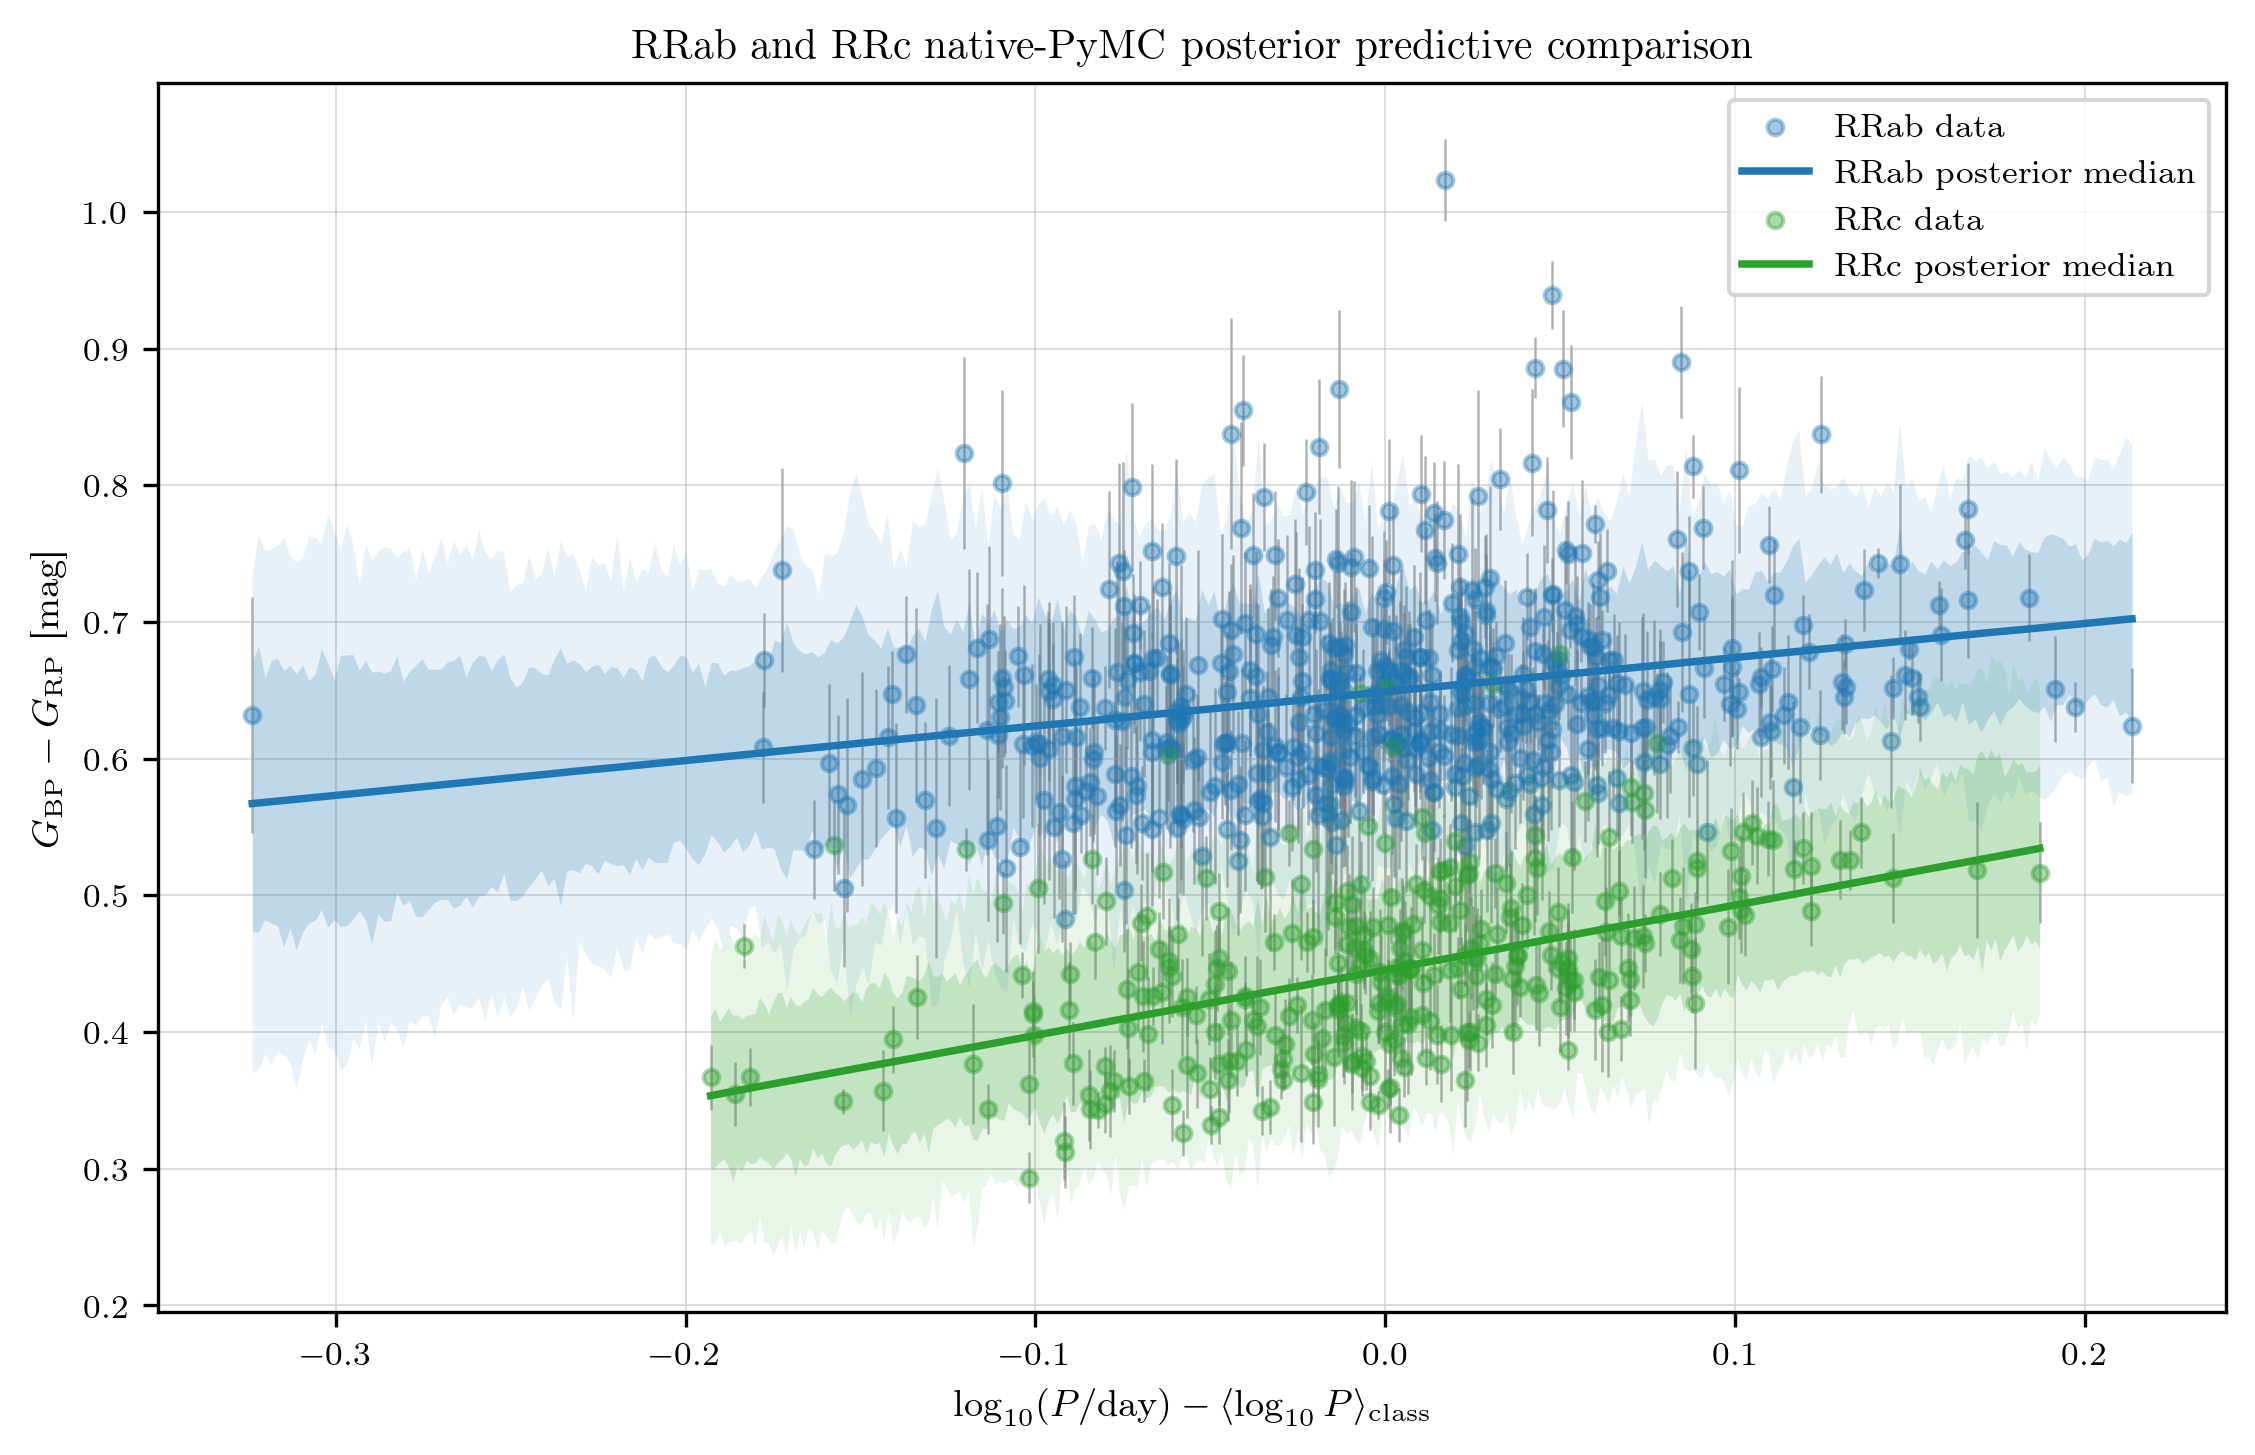

In [9]:
for rr_class in RR_CLASSES:
    ax = plot_pc_posterior_predictive(
        pc_results[rr_class]["ctx"],
        pc_results[rr_class]["samples"],
    )
    ax.set_title(f"{rr_class} posterior predictive check (native PyMC NUTS)")
    plt.show()

ax = plot_pc_posterior_predictive_comparison(
    pc_results["RRab"]["ctx"],
    pc_results["RRab"]["samples"],
    pc_results["RRc"]["ctx"],
    pc_results["RRc"]["samples"],
)
ax.set_title("RRab and RRc native-PyMC posterior predictive comparison")
plt.show()


## Analysis and Discussion

The RRab and RRc fits should be interpreted as related but not interchangeable color-period calibrations. They represent different pulsation modes, so agreement between the two subclasses is an empirical question rather than something to assume in advance.

For MCMC interpretation, the important distinction is between **posterior correlation** and **chain correlation**. The corner plot shows posterior correlation: even after centering, the slope and intercept can remain correlated because different parameter combinations describe nearly the same mean relation over the observed period range. The trace plot, by contrast, is about chain correlation and mixing: it should not show long sticky plateaus, strong trends after burn-in, or obvious failures to explore the posterior support.

A scientifically acceptable result here is therefore not just a narrow posterior. It is a combination of three things: sensible posterior geometry in the corner plots, stable traces without obvious pathologies, and posterior predictive envelopes that span the observed RRab and RRc color sequences once the quoted color errors, propagated period term, and inferred $\sigma_{c,\mathrm{scatter}}$ are all included. That intrinsic-scatter term should be read as unresolved astrophysical width in the Gaia color relation, not as mere numerical slack.

The notebook still uses one chain per class for pedagogy and runtime. That is enough to illustrate the period-color relation and its main covariance structure, but it is weaker than a research-grade convergence argument. A more complete workflow would add multiple chains, $\hat{R}$, effective sample size, lag-autocorrelation summaries, and explicit divergence checks before treating the posterior sample as fully validated.


## Notebook Handoff

This notebook now uses the shared RRab/RRc Gaia cache created near the start of the notebook and writes the reddening-stage fit artifact directly into `labs/01/`:

- `rrlyrae_rrab_rrc_full_catalog.npz` stores the shared RRab/RRc Gaia full-join cache used by `05.ipynb`, `06.ipynb`, and later dust-stage notebooks.
- `rrlyrae_optical_pc_comparison_data.npz` stores the summarized RRab and RRc Gaia period-color relation values and predictive summaries used by `06.ipynb`.


In [10]:
pc_output_path = Path('rrlyrae_optical_pc_comparison_data.npz')
save_optical_pc_comparison_data(pc_output_path, pc_comparison_export)

{
    'pc_artifact': str(pc_output_path.resolve()),
    'classes': list(pc_comparison_export),
    'shared_catalog_path': str(shared_catalog_path.resolve()),
    'shared_catalog_rows': len(rrlyrae_rrab_rrc_full),
}


{'pc_artifact': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_optical_pc_comparison_data.npz',
 'classes': ['RRab', 'RRc'],
 'shared_catalog_path': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_rrab_rrc_full_catalog.npz',
 'shared_catalog_rows': 269772}